# Example Levee trajectory N27-2

Get an overview of levee charcateristics for levee trajectory 27-2.

Thanks to package `GeoProfile` that allows to visualise [geotechnical data in Python](https://github.com/cemsbv/GeoProfile/tree/main/docs).

In [1]:
import pickle
import os
import datetime

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm

import logging
#logging.basicConfig(level=logging.DEBUG)
# when logging level = DEBUG, skip messages some message
#for lib in ['rasterio', 'matplotlib', 'PIL', 'urllib3']:
#    logging.getLogger(lib).setLevel(logging.INFO)
logging.basicConfig(level=logging.INFO)

In [2]:
import hydropandas as hpd
hpd.__version__

'0.18.0'

In [5]:
import geoprofile
geoprofile.__version__

'0.4.0'

In [6]:
# code should be changed to OOP style, but for now, we will use procedural style
# https://github.com/scheldestromen/geolookup/issues/2
import sys
sys.path.append(r'..\..\geolookup')
import functions as gl

# Open data

In [7]:
DATA_PATH = r'N27-2_data\\'
PLOT_PATH = r'N27-2_plots\\'

In [8]:
# choose whether to run longer functions or not
#run_longer_functions = False
run_longer_functions = True
# since April 2026 I have issues saving the Plotly plots as PNG, so I will not save the images for now
write_image = False

In [9]:
# Choose which region and dikepoles to analyse
region = 'Os'
dp_min = 725
dp_max = 1080
dp_max_gwl = 950 # groundwater levels in GitHub till this dp, otherwise file is too large to upload

## CPTs

Downloaded from Broloket and classified via `CPTcore` using Robertson classification.

In [10]:
cpt_classification = 'Robertson'

fn = DATA_PATH + f'geoprofile_columns_robertson_{region}_dp{dp_min}-{dp_max}.pkl'
logging.info(f"File last modified: {datetime.datetime.fromtimestamp(os.path.getmtime(fn)) - datetime.datetime.now()}")
with open(fn, "rb") as f:
    geoprofile_cols = pickle.load(f)
gl.describe_columns(geoprofile_cols)

INFO:root:File last modified: -5 days, 0:16:30.056329
INFO:root:Number of columns: 1248
INFO:root:Dike pole range: dp726.6 - dp1081.5, total 759 unique dike poles.
INFO:root:Data X: centered at 64380 with span 13 km, Y: centered at 397930 with span 11 km


Mind that data has been pre-processed to make section perpendicular to the levee. Property `dp` is included to the dikepole where each CPT is situated. Property `distance_to_ref` is the distance to the reference line (usually on the crest). [Enhancement](https://github.com/scheldestromen/geolookup/issues/3).

In [11]:
geoprofile_cols[0].dp, geoprofile_cols[0].distance_to_ref

(np.float64(780.8), np.float64(-1125.521012243663))

## Boreholes

[To be added](https://github.com/scheldestromen/geolookup/issues/5).

## Dikepoles

Signs every 100 m on the levees.

In [12]:
df_hm = pd.read_csv(DATA_PATH + f'table_dijkpalen_{region}_dp{dp_min}-{dp_max}.csv')
df_hm.head()

,x,y,name,region,dp
0,70889.6373,402526.2868,Oosterschelde,Os,725.0
1,70848.0028,402553.4726,Oosterschelde,Os,725.5
2,70801.6659,402571.8213,Oosterschelde,Os,726.0
3,70752.1945,402577.7330,Oosterschelde,Os,726.5
4,70702.6648,402571.6137,Oosterschelde,Os,727.0


## Schematised surface level of levee profiles

Profiles of surface level. Each line is a profile. It has columns for all x,y locations.

In [13]:
df_profile = pd.read_csv(DATA_PATH + f'table_profielen_{region}_dp{dp_min}-{dp_max}.csv')
# Check if the DataFrame columns contain both 'bin' and 'kruin'
df_profile.loc[:, ['dp'] + df_profile.columns[df_profile.columns.str.contains('bin|kruin')].to_list()].head()

,dp,xmv.bin,xkruin.1,xkruin.2,ymv.bin,ykruin.1,ykruin.2
0,725.0,-91.13,-3.404,2.238,1.203,6.39,6.22
1,726.0,-200.88,-2.953,-0.385,1.329,6.43,6.41
2,727.0,-51.22,-2.084,-0.067,1.342,6.51,6.43
3,728.0,-201.00,-2.665,-0.833,1.158,6.45,6.37
4,729.0,-201.00,-2.764,-0.546,1.222,6.46,6.42


## Section profiles Deltaversterking

Drawings of Deltaversterking. DataFrame of distances along trajectory where drawing  is available.

In [23]:
df_section = pd.read_csv(DATA_PATH + f'table_deltaversterking_{region}_dp{dp_min}-{dp_max}.csv')
df_section['description'] = 'Deltaversterking'
df_section.dsn_file_tif = DATA_PATH + df_section.dsn_file_tif 
df_section.head()

,region,dp,dsn_file_tif,description
0,Os,725.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking
1,Os,730.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking
2,Os,734.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking
3,Os,736.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking
4,Os,744.9,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking


In [ ]:
# column x_offset is used to shift the deltaversterking drawing in the x-direction, 
#  when x=0 is different in drawing compared to current refline.
df_section['x_offset'] = 0
df_section.loc[df_section.dp == 725.5, 'x_offset'] = -8
df_section.loc[df_section.dp == 730.5, 'x_offset'] = 3
df_section.loc[df_section.dp == 736.5, 'x_offset'] = -5
df_section.loc[df_section.dp == 744.9, 'x_offset'] = -6
df_section.loc[df_section.dp == 753.1, 'x_offset'] = -5
df_section.loc[df_section.dp == 873.2, 'x_offset'] = -5
df_section.loc[df_section.dp == 934.9, 'x_offset'] = -13
df_section.loc[df_section.dp == 940, 'x_offset'] = 5
df_section.loc[df_section.dp == 945, 'x_offset'] = 5
df_section.loc[df_section.dp == 950, 'x_offset'] = 7
df_section.loc[df_section.dp == 953, 'x_offset'] = -8
df_section.loc[df_section.dp == 956.8, 'x_offset'] = -9
df_section.loc[df_section.dp == 961.5, 'x_offset'] = -9
df_section.loc[df_section.dp == 964, 'x_offset'] = -9
df_section.loc[df_section.dp == 968.8, 'x_offset'] = -10
df_section.loc[df_section.dp == 971.3, 'x_offset'] = -9
df_section.loc[df_section.dp == 981, 'x_offset'] = -12

Example of one plot of Deltaversterking drawing and surface level profile. 

Result is shown in your browser. Hardcopy example is in this markdown cell as well.

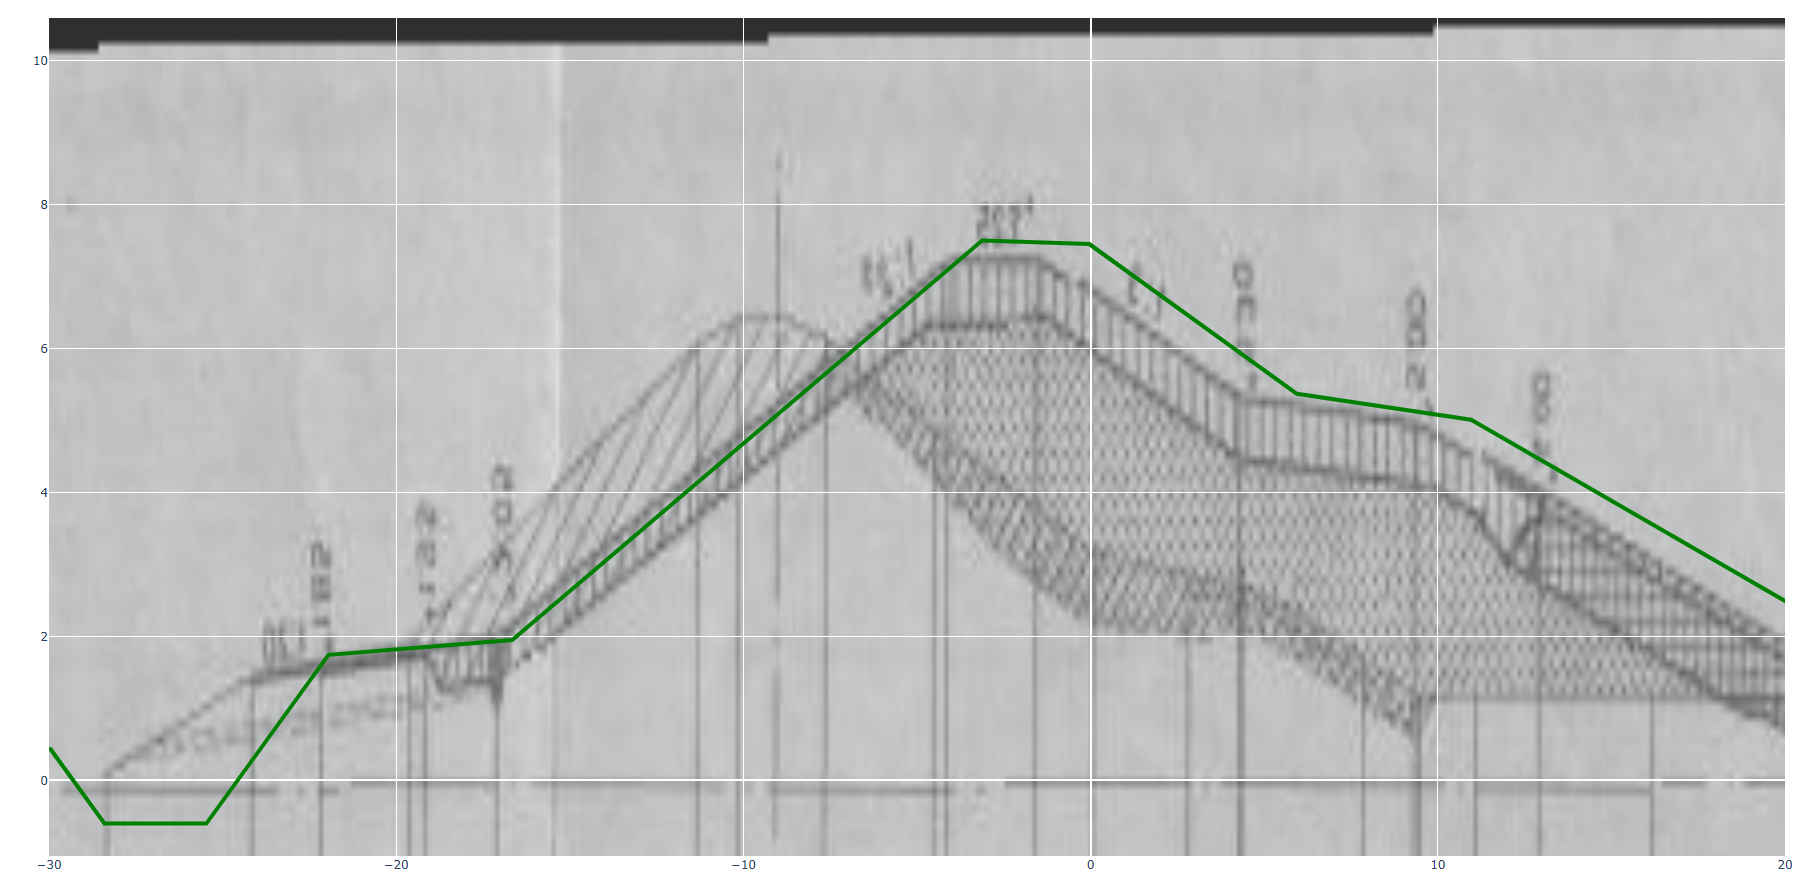

In [40]:
dp_fig = 981
dp_center = 981
fn = df_section.loc[df_section.dp == dp_fig, 'dsn_file_tif'].values[0]

print(fn)
from plotly.subplots import make_subplots
import plotly.io as pio

figure = make_subplots(
        rows=1,
        cols=1,
        horizontal_spacing=0.01,
    )

gl.plot_deltaversterking_background(figure, fn, dp=None, fig_row=1, fig_col=1, x_offset=-12)
gl.select_and_plot_surfacelevelprofile(dp_center, figure, df_profile, delta_dp=0, region='Os', fig_row=1, fig_col=1)

figure.update_xaxes(range=[-30, 20], row=1, col=1)
pio.write_html(figure, file=os.path.join(PLOT_PATH, 'test.html'), auto_open=True)

N27-2_data\\deltaversterking\os0930-0987\doorsnedes\dsn2_flipped.tif


## Groundwater monitoring and time series
Using `HydroPandas`

In [17]:
#TODO: functie maken die ouderom netjes aangeeft, als > dag, in dagen, anders in uren, anders in minuten
fn = DATA_PATH + f'oc_gmw_{region}_dp{dp_min}-{dp_max_gwl}.pkl'
# to make plot of all data
fn = r'c:\data\python\cloned\N27-2\data\obs\oc_gmw_os_dp725-1080.pkl'
oc_gwl = hpd.read_pickle(fn)
logging.info(f"File last modified: {(datetime.datetime.fromtimestamp(os.path.getmtime(fn)) - datetime.datetime.now()).total_seconds() / 60:.2f} minutes")
gl.describe_oc(oc_gwl, expected_obs_interval=10)


INFO:root:File last modified: -5715.44 minutes
INFO:root:Obs Collection has 128 monitoring wells, on 67 locations.
INFO:root:45 monitoring wells have no observations, 83 have observations.
INFO:root:First observation 2007-08-29, last observation 2025-11-22
INFO:root:Obs Collection has on average 1.1 years of observations per monitoring well, median 1.3 years. Assuming observations interval each 10 minutes.
INFO:root:Data X: centered at 64220 with span 13 km, Y: centered at 398040 with span 11 km
INFO:root:Index is unique.


The ObservationCollection has both timeseries and metadata in one row.

<Axes: title={'center': 'grondwater level, screen: 1.2 - 0.2 mNAP'}>

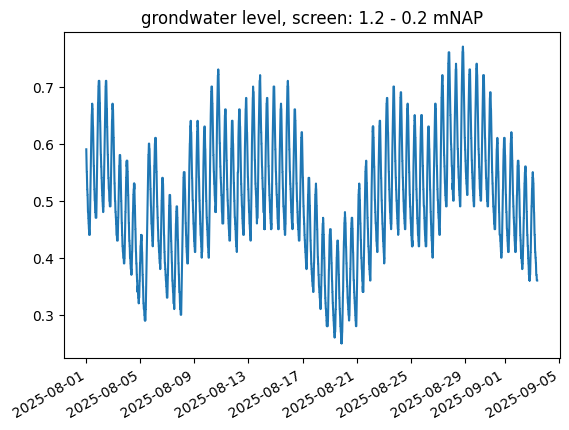

In [18]:
oc_gwl.iloc[-1].obs['2025-08':].gwl_mnap.plot(
    title=f'grondwater level, screen: {oc_gwl.iloc[-1].screen_top:0.1f} - {oc_gwl.iloc[-1].screen_bottom:0.1f} mNAP'
)


# Section along the trajectory of the levee

Using the standard `profile` function of `GeoProfile`. It is called within a specific `GeoLookup` function, that creates the path.
Afterwards levee charecteristics are added to the plot. That uses the `dp` (hectometer) property of these data sets.

Section opens in a browser window. Map is included in notebook. Section is included in this markdown cell for reference.

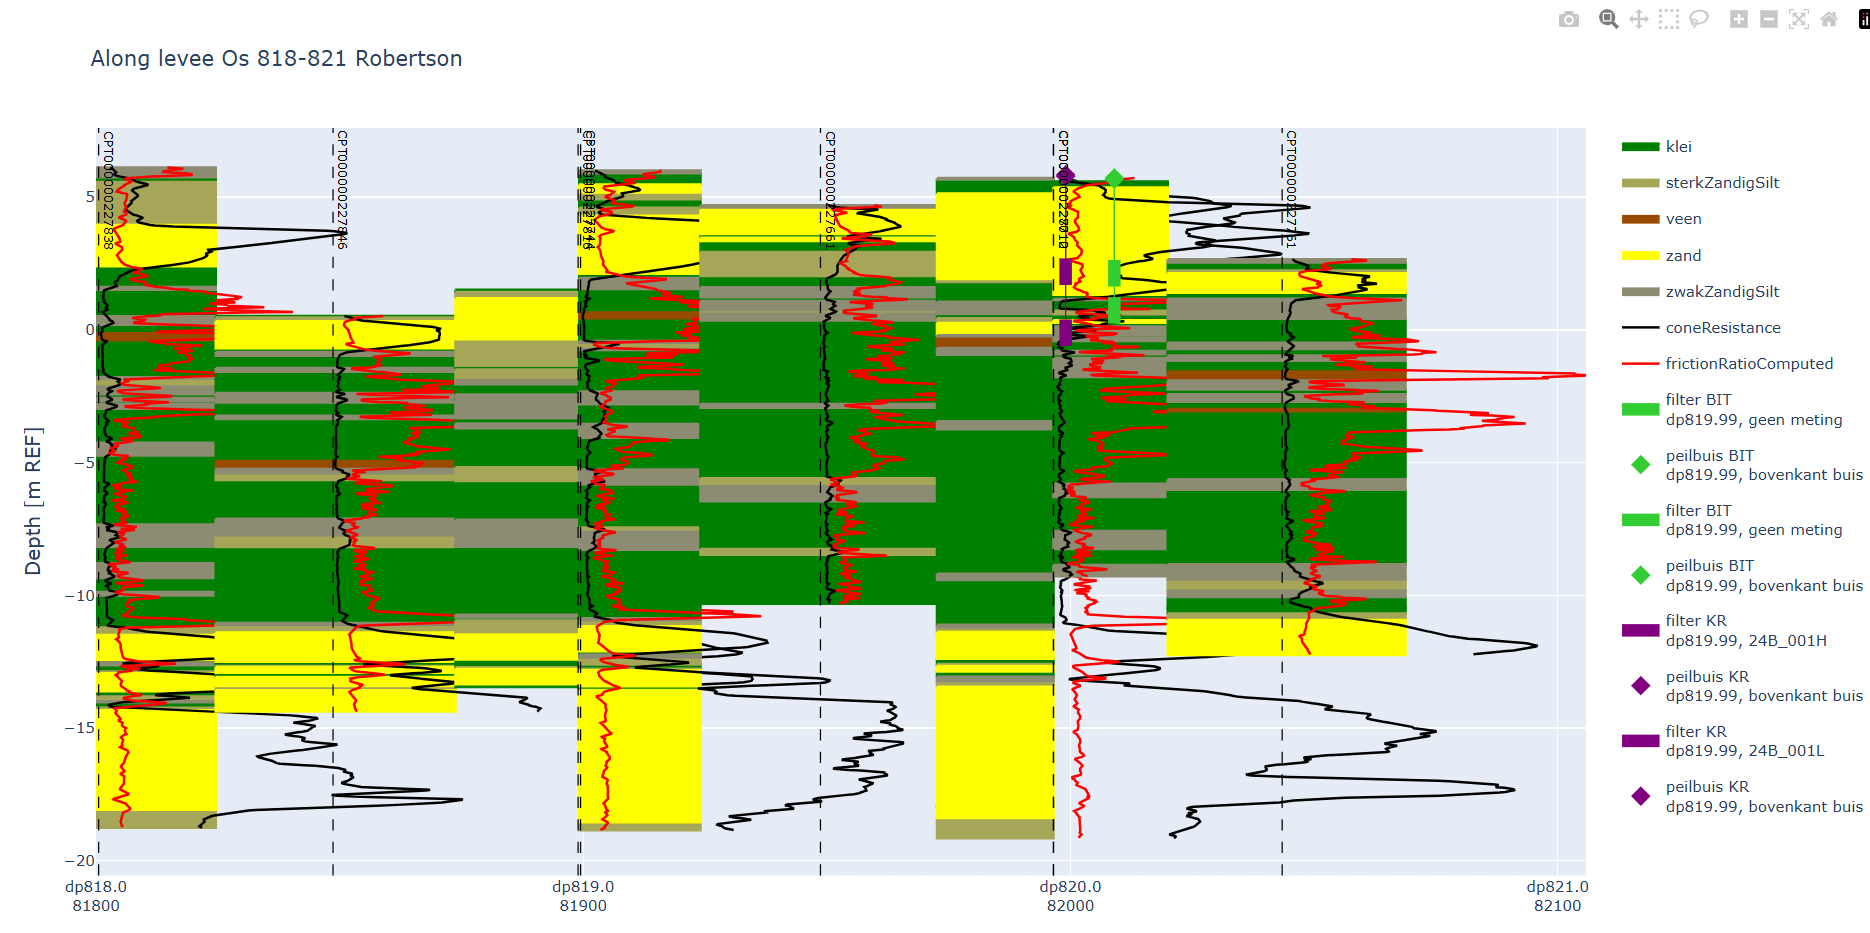

Issue: [Standpipes not visible on map](https://github.com/scheldestromen/geolookup/issues/4)

INFO:root:Added 4 points to map for dps [818 819 820 821], type is <class 'pandas.core.frame.DataFrame'>.
INFO:root:Added 0 points to map for dps [818 819 820 821], type is <class 'hydropandas.obs_collection.ObsCollection'>.
Add column to profile: 100%|██████████| 8/8 [00:01<00:00,  4.63it/s]
INFO:root:Plotting 4 standpipes in figure, method=geoprofile.


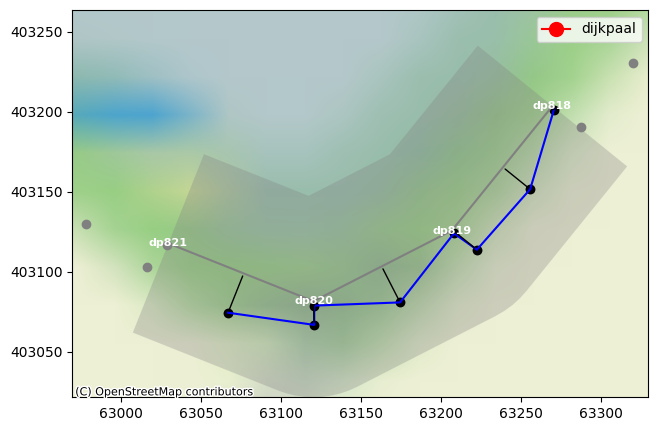

In [21]:
dp_list = np.arange(818, 821+1)
fig, profile = gl.plot_geoprofile(
    geoprofile_cols, 
    df_hm, 
    dp_list,
    oc_gwl=oc_gwl, 
    buffer=60, 
    projectname=f"Along levee {region} {min(dp_list)}-{max(dp_list)} {cpt_classification}",
    title_suffix='',
    plot_path=PLOT_PATH,
    write_image=write_image)

Plotting profiles:   0%|          | 0/36 [00:00<?, ?it/s]

KeyboardInterrupt: 

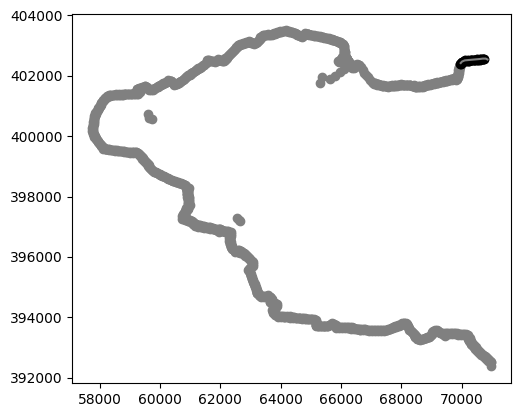

In [22]:
if run_longer_functions:
    for dp_start in tqdm(range(dp_min, dp_max+1, 10), desc="Plotting profiles"):
        dp_end = min(dp_start + 10, dp_max)
        dp_list = np.arange(dp_start, dp_end + 1)
        fig, profile = gl.plot_geoprofile(
            geoprofile_cols, 
            df_hm, 
            dp_list,
            oc_gwl=oc_gwl, 
            buffer=60, 
            projectname=f"Along levee {region} {min(dp_list)}-{max(dp_list)} {cpt_classification}",
            title_suffix='',
            plot_path=PLOT_PATH,
            auto_open=False,
            write_image=write_image)

# Doorsnede maken bij dijkpaal

Een doorsnede haaks op de dijk, ter hoogte van een dijkpaal. Weergegeven wordt het beschikbare grondonderzoek, de dichtstbijzijnde versterkingstekening van de Deltaversterking, het actuele maaiveld profiel en de peilbuizen.

Doel is om in de doorsnede meer weer te geven dan de huidige locatie. Daarom worden sonderingen en peilbuizen van meerdere dijkpalen weergegeven wanneer de `delta_dp` variabele wort gebuikt. Informatie van lagere dijkpalen krijgt een rode tint, informatie van hogere dijkpalen een blauwe.

Grondonderzoek wordt geprojecteerd ten opzichte van de referentielijn. Het wordt nooit bovenopelkaargeplot. Dan krijgt het een offset. Die offset is weergegeven tussen de haakjes in het label. Grondonderzoek van de opgevraagde raai wordt als eerste geplot, en staat dus vrijwel altijd op de juiste plek.

Doorsnede opent in browser. In deze cel een screendump.

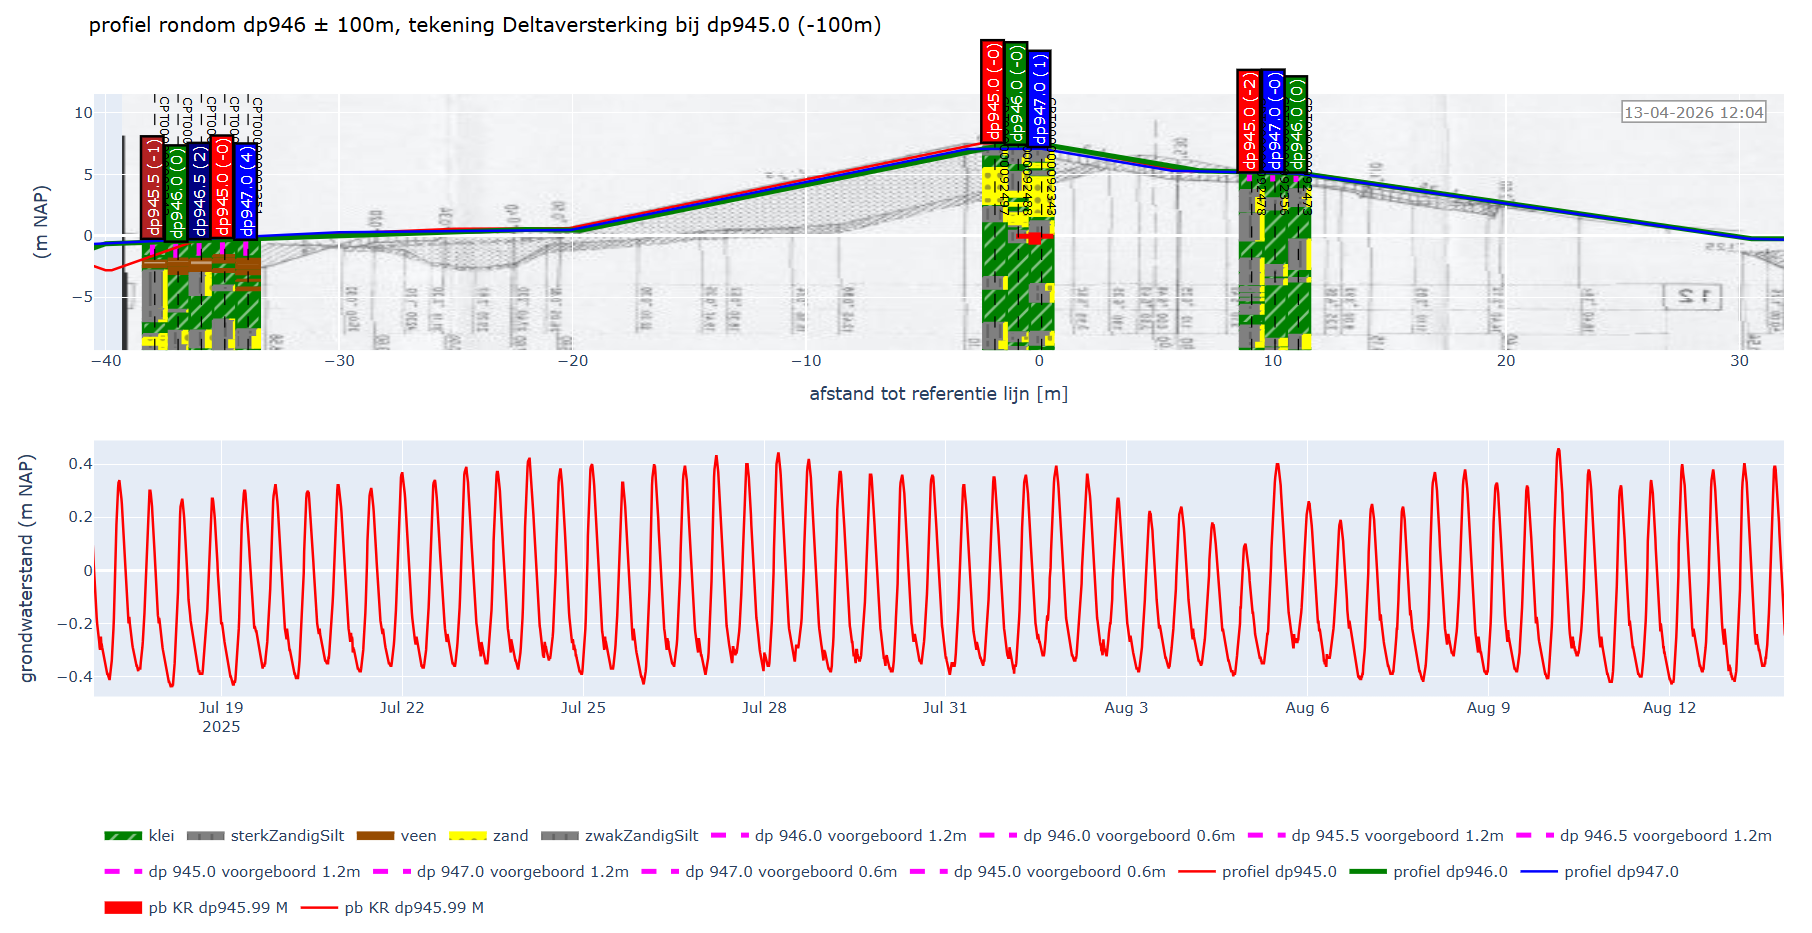



In [20]:
dp_center = 935
delta_dp = 2

fig, fn = gl.create_figure_for_dp(
    dp_center, 
    df_section, 
    geoprofile_cols, 
    df_profile,
    oc_gwl,
    delta_dp=delta_dp,
    plot_gwl=True,
    plot_path=PLOT_PATH,
    ylims_upper=[-4, 7],
    write_image=write_image
    )

INFO:root:Plotting 4 standpipes in figure, method=by_dp.


# Overview for standpipe analysis

Plot sections for all locations with a section or a standpipe

In [21]:
final_dps = gl.filter_relevant_dps(df_section, oc_gwl)

INFO:root:In df_sections are 67 locations (725.5, 730.5, 734.5, 736.5, 744.9, 753.1, 754.5, 760.3, 763.3, 768.4, 773.4, 777.5, 804.5, 809.4, 812.5, 818.1, 829.8, 837.4, 843.5, 846.7, 854.5, 857.3, 863.5, 865.0, 868.0, 873.2, 880.8, 886.0, 889.2, 892.5, 898.0, 903.5, 908.7, 914.0, 919.0, 922.0, 929.0, 934.9, 940.0, 945.0, 950.0, 953.0, 956.8, 961.5, 964.0, 968.8, 971.3, 974.0, 977.0, 981.0, 986.2, 996.2, 1001.0, 1007.0, 1015.3, 1022.4, 1026.0, 1033.5, 1045.3, 1055.5, 1055.5, 1059.0, 1059.0, 1066.3, 1066.3, 1073.3, 1073.3)
INFO:root:In oc_gwl are 74 locations (738.0, 738.01, 748.99, 749.0, 761.99, 762.0, 772.0, 777.5, 777.51, 781.63, 781.65, 783.02, 783.11, 784.37, 784.43, 789.01, 789.02, 792.99, 793.0, 796.99, 819.99, 853.98, 853.99, 866.03, 866.04, 868.67, 868.75, 869.56, 869.93, 882.04, 882.06, 893.95, 894.0, 917.06, 917.07, 917.09, 930.5, 931.07, 934.99, 935.02, 940.99, 941.0, 945.99, 955.02, 961.0, 963.99, 969.99, 970.01, 975.0, 980.0, 982.79, 982.99, 987.93, 987.99, 991.0, 995.79, 

In [22]:
final_dps

if not run_longer_functions:
    loop_over_dps = final_dps[:2]
else:
    loop_over_dps = final_dps

for dp_center in tqdm(loop_over_dps, desc="Plotting profiles"):
    
    fig, fn = gl.create_figure_for_dp(
        dp_center, 
        df_section, 
        geoprofile_cols, 
        df_profile,
        oc_gwl,
        delta_dp=delta_dp,
        plot_gwl=True,
        plot_path=PLOT_PATH,
        ylims_upper=[-4, 7],
        auto_open=False,
        write_image=write_image,
        )

Plotting profiles:   0%|          | 0/87 [00:00<?, ?it/s]

INFO:root:Plotting 3 standpipes in figure, method=by_dp.
INFO:root:No observations for GMW000000114193-1 dp738.0, skipping plot.
INFO:root:No observations for GMW000000114192-2 dp738.0, skipping plot.
INFO:root:No observations for GMW000000114192-1 dp738.0, skipping plot.
INFO:root:Plotting 4 standpipes in figure, method=by_dp.
INFO:root:No observations for GMW000000114193-1 dp738.0, skipping plot.
INFO:root:No observations for GMW000000114192-2 dp738.0, skipping plot.
INFO:root:No observations for GMW000000114192-1 dp738.0, skipping plot.
INFO:root:No observations for GMW000000114191-1 dp738.0, skipping plot.
INFO:root:Plotting 8 standpipes in figure, method=by_dp.
INFO:root:No observations for GMW000000114194-2 dp749.0, skipping plot.
INFO:root:No observations for GMW000000114194-1 dp749.0, skipping plot.
INFO:root:No observations for GMW000000114196-3 dp749.0, skipping plot.
INFO:root:No observations for GMW000000114196-2 dp749.0, skipping plot.
INFO:root:No observations for GMW0000

Section without depth limit on y-axis.

In [ ]:
for dp_center in loop_over_dps:
    delta_dp = 2

    fig, fn = gl.create_figure_for_dp(
        dp_center, 
        df_section, 
        geoprofile_cols, 
        df_profile,
        oc_gwl,
        delta_dp=delta_dp,
        plot_gwl=False,
        plot_path=PLOT_PATH,
        auto_open=False,
        write_image=write_image,
        )

: 

: 